###### Use quantization 
https://github.com/bitsandbytes-foundation/bitsandbytes

# TinyGPT

**Author: Abraham R.**

The following notebook is an example of a really tiny GPT based model called TinyGPT.
You'll review the GPT architecture (transformer decoder) and implement the following tasks:

## TinyGPT Architecture

Tailored for the [NLP-II course](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG) as we deal with architectures and theory, this model consists of a **Mixture of Experts GPT**, equivalent to models like:
- DeepSeek
- Mistral

## Tasks

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)

## Architecture:
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

## What to expect?

- You'll manage to understand a depth implementation of a GPT model.
- Implement a MoE Layer to create a state-of-the art GPT model.
- Explore decoding algorithms for text generation.


### NOTE

Tokenization is out of scope, we'll use a simple yet ineffective character-based tokenizer.


In [22]:
import torch
import torch.nn.functional as F
import httpx
import matplotlib.pyplot as plt
import pprint # Import Pretty Print Library for formatted output (Pprint)


from torch import nn
from torch.utils.data import Dataset, DataLoader
from trainer import Trainer
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from dataclasses import dataclass, field
from typing import Optional, List, Type

## Downloading Dataset

In [23]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = httpx.get(url)
text = response.text

text = text[:100_000]  # Using 100k characters for speedup
print(text)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Character-based encoding

In [24]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
def encode(s): return [stoi[c] for c in s]
def decode(l): return ''.join([itos[i] for i in l])
data = torch.tensor(encode(text), dtype=torch.long)

# Train/test split
split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]

# Dataloaders

In [25]:
class CharDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.block_size]
        y = self.data[idx + 1 : idx + self.block_size + 1]
        return x, y

# GPT Configuration

In [26]:
@dataclass
class MoEArgs:
    """
    MoE input arguments class.
    """
    num_experts : int = field(default=4)
    #num_experts_per_token : int = field(default=2)
    top_k: int = field(default=2)  # Number of experts each token uses
    capacity_factor: float = 1.25   # Buffer for load balancing (optional)
    load_balance_loss_coef: float = 0.01  # Weight for auxiliary loss

@dataclass
class GPTConfig:
    """
    Base class for GPT models.
    """
    block_size: int = 32
    batch_size: int = 8
    n_embd: int = 64
    n_head: int = 4
    n_layer: int = 2
    dropout: float = 0.1
    vocab_size: int = vocab_size
    bias: bool = True
    ff_class: Optional[Type[nn.Module]] = None
    moe : Optional[MoEArgs] = None

config = GPTConfig()
print(config.__dict__)

{'block_size': 32, 'batch_size': 8, 'n_embd': 64, 'n_head': 4, 'n_layer': 2, 'dropout': 0.1, 'vocab_size': 61, 'bias': True, 'ff_class': None, 'moe': None}


In [27]:
train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset,
                        batch_size=config.batch_size,
                        shuffle=True,
                        drop_last=True,
                        pin_memory=True,
                        num_workers=0, # if using mps set num_workers as 0.
                        )
val_loader = DataLoader(val_dataset,
                        batch_size=config.batch_size,
                        shuffle=False,
                        drop_last=True,
                        pin_memory=True,
                        num_workers=0,
                        )

In [28]:
class AttentionHead(nn.Module):
    """
    Scaled Dot-Product Attention Head for Multi-Head Attention.
    """
    def __init__(self, args: GPTConfig) -> None:
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.head_dim = args.n_embd // args.n_head

        # Combined QKV projection
        self.key_query_value = nn.Linear(args.n_embd, 3 * self.head_dim, bias=args.bias)

        self.dropout = nn.Dropout(args.dropout)
        self.block_size = args.block_size
        self.register_buffer('tril', torch.tril(torch.ones(args.block_size, args.block_size)))

    def forward(self, x: torch.Tensor, kv_cache: Optional[torch.Tensor] = None, return_weights=False):
        B, T, C = x.shape
        key_query_value = self.key_query_value(x)  # (B, T, 3 * head_dim)
        k, q, v = torch.chunk(key_query_value, 3, dim=-1)  # (B, T, head_dim) each

        if kv_cache is not None:
            key_cache, value_cache = kv_cache.unbind(dim=0)  # (B, T', head_dim)
            k = torch.cat((key_cache, k), dim=1)
            v = torch.cat((value_cache, v), dim=1)

        # Scaled dot-product attention
        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)  # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        out = wei @ v  # (B, T, head_dim)

        if return_weights:
            return out, wei

        if kv_cache is not None:
            return out, torch.stack((k, v))

        return out, None

In [29]:
class MultiHeadAttention(nn.Module):
    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd must be divisible by n_head"
        self.n_heads = args.n_head
        self.head_dim = args.n_embd // args.n_head

        self.heads = nn.ModuleList([
            AttentionHead(args) for _ in range(self.n_heads)
        ])

        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)
        self.dropout = nn.Dropout(args.dropout)

    def forward(self, x, kv_cache=None, return_weights=False):
        all_outputs = []
        all_weights = []
        new_kv_cache = [] if kv_cache is not None else None

        for i, head in enumerate(self.heads):
            head_cache = kv_cache[i] if kv_cache is not None else None
            out, weights_or_kv = head(x, kv_cache=head_cache, return_weights=return_weights)
            all_outputs.append(out)
            if return_weights:
                all_weights.append(weights_or_kv)
            if kv_cache is not None:
                new_kv_cache.append(weights_or_kv)  # weights_or_kv is new kv_cache here

        concat = torch.cat(all_outputs, dim=-1)  # concat along embedding dim
        out = self.dropout(self.proj(concat))

        if return_weights:
            return out, torch.stack(all_weights)
        if kv_cache is not None:
            return out, new_kv_cache
        return out

In [30]:
class FeedForward(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)

class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias),
            nn.Dropout(config.dropout)
        ) 

    def forward(self, x) -> torch.Tensor:
        """
        Args:
            x: [num_tokens, n_embd] - tokens routed to this expert
        Returns:
            [num_tokens, n_embd] - expert output
        """
        return self.net(x)


class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.top_k = config.moe.top_k  # How many experts to select per token
        self.num_experts = config.moe.num_experts
        # Linear layer to produce logits for each expert
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x: torch.Tensor):
        """
        Args:
            x: [batch, seq_len, n_embd] - input tokens
            
        Returns:
            top_k_gates: [batch, seq_len, top_k] - weights for selected experts
            top_k_indices: [batch, seq_len, top_k] - which experts are selected
            gates_full: [batch, seq_len, num_experts] - full gate distribution (for load balancing)
        """
        # Get logits for all experts
        logits = self.proj(x)  # [batch, seq_len, num_experts]
        
        # Select top-k experts per token
        top_k_logits, top_k_indices = torch.topk(logits, self.top_k, dim=-1)
        # top_k_logits: [batch, seq_len, top_k]
        # top_k_indices: [batch, seq_len, top_k]
        
        # Normalize top-k logits to get weights (softmax over selected experts)
        top_k_gates = F.softmax(top_k_logits, dim=-1)
        
        # Create full gate distribution for load balancing loss
        # This shows which experts each token chose
        zeros = torch.zeros_like(logits)  # [batch, seq_len, num_experts]
        gates_full = zeros.scatter(dim=-1, index=top_k_indices, src=top_k_gates)
        
        return top_k_gates, top_k_indices, gates_full

class MoELayer(nn.Module):
    """
    Mixture of experts FeedForward Layer
    """

    # def __init__(self, experts : List[nn.Module], gate : nn.Module, moe_args : MoEArgs):
    #     super().__init__()
    #     self.experts = nn.ModuleList(experts)
    #     self.gate = gate
    #     self.args = moe_args

    def __init__(self, config:GPTConfig):
        super().__init__()
        assert config.moe is not None, "MoEArgs must be provided in config"

        self.num_experts = config.moe.num_experts
        self.top_k = config.moe.top_k
        self.n_embd = config.n_embd

        # Create the experts networks
        self.experts = nn.ModuleList([
            Expert(config) for _ in range(self.num_experts)
        ])

        # Create the gating network
        self.gate = Gate(config)


    def forward(self, x: torch.Tensor):
        """
        Args:
            x: [batch, seq_len, n_embd] - input tokens
            
        Returns:
            output: [batch, seq_len, n_embd] - weighted expert outputs
            gates_full: [batch, seq_len, num_experts] - gate distribution for loss
        """
        batch_size, seq_len, n_embd = x.shape
        
        # Step 1: Get routing decisions from gate
        top_k_gates, top_k_indices, gates_full = self.gate(x)
        # top_k_gates: [batch, seq_len, top_k]
        # top_k_indices: [batch, seq_len, top_k]
        # gates_full: [batch, seq_len, num_experts]
        
        # Step 2: Flatten for easier token routing
        x_flat = x.view(-1, n_embd)  # [batch*seq_len, n_embd]
        top_k_indices_flat = top_k_indices.view(-1, self.top_k)  # [batch*seq_len, top_k]
        top_k_gates_flat = top_k_gates.view(-1, self.top_k)      # [batch*seq_len, top_k]
        
        # Step 3: Initialize output tensor
        output_flat = torch.zeros_like(x_flat)  # [batch*seq_len, n_embd]
        
        # Step 4: Route tokens to experts and accumulate weighted outputs
        for expert_idx in range(self.num_experts):
            # Find which tokens are routed to this expert
            # expert_mask: [batch*seq_len, top_k] - True where this expert is selected
            expert_mask = (top_k_indices_flat == expert_idx)
            
            # Get flat indices of tokens and their k-position
            token_indices, k_indices = torch.where(expert_mask)
            
            if len(token_indices) == 0:
                continue  # No tokens routed to this expert
            
            # Step 4a: Extract tokens for this expert
            expert_input = x_flat[token_indices]  # [num_routed_tokens, n_embd]
            
            # Step 4b: Apply expert network
            expert_output = self.experts[expert_idx](expert_input)  # [num_routed_tokens, n_embd]
            
            # Step 4c: Get corresponding gate weights
            expert_weights = top_k_gates_flat[token_indices, k_indices].unsqueeze(-1)  
            # [num_routed_tokens, 1]
            
            # Step 4d: Accumulate weighted output
            output_flat[token_indices] += expert_weights * expert_output
        
        # Step 5: Reshape back to original dimensions
        output = output_flat.view(batch_size, seq_len, n_embd)
        
        return output

class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        # Validate configuration
        if config.moe is None:
            raise ValueError(    "MoEFFN requires config.moe to be set. "
                                  "Use standard MLP instead if not using MoE."
                )
        
        self.moe = MoELayer(config)

    def forward(self, x):
        output, gates = self.moe(x)
        return output, gates
    
    def extra_repr(self) -> str:
        """String representation for print(model)"""
        return f'num_experts={self.moe.num_experts}, top_k={self.moe.top_k}'

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        # Choose feedforward class
        if config.ff_class is not None:
            # User explicitly specified a feedforward class
            self.ff = config.ff_class(config)
            self.use_moe = isinstance(self.ff, MoEFFN)
        elif config.moe is not None:
            # MoE is configured, use MoEFFN
            self.ff = MoEFFN(config)
            self.use_moe = True
        else:
            # Default to standard feedforward
            self.ff = FeedForward(config)
            self.use_moe = False

    def forward(self, x, kv_cache=None, return_weights=False):
        attn_out = self.attn(self.ln1(x), kv_cache=kv_cache, return_weights=return_weights)
        if return_weights:
            attn_out, weights = attn_out
        else:
            weights = None

        if isinstance(attn_out, tuple):
            attn_out, updated_kv = attn_out
        else:
            updated_kv = None
        
        x = x + attn_out
        
        # Handle MoE output
        ff_out = self.ff(self.ln2(x))
        if self.use_moe and isinstance(ff_out, tuple):
            ff_out, _ = ff_out  # Discard gates for now

        x = x + ff_out

        #x = x + self.ff(self.ln2(x))
        return (x, updated_kv, weights) if return_weights else (x, updated_kv)

## TinyGPT Architecture

In [31]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.config = config

    def forward(self, idx, kv_cache=None, return_weights=False):
        B, T = idx.shape
        tok_emb = self.token_emb(idx)
        pos = torch.arange(T, device=idx.device)
        pos_emb = self.pos_emb(pos)[None, :, :]
        x = tok_emb + pos_emb

        new_kv_cache = [] if kv_cache is not None else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_kv = kv_cache[i] if kv_cache is not None else None
            if return_weights:
                x, updated_kv, weights = block(x, kv_cache=layer_kv, return_weights=True)
                all_weights.append(weights)  # weights shape: (n_heads, B, T, T)
            else:
                x, updated_kv = block(x, kv_cache=layer_kv)
            if kv_cache is not None:
                new_kv_cache.append(updated_kv)

        x = self.ln_f(x)
        logits = self.head(x)

        if return_weights:
            if kv_cache is not None:
                return logits, new_kv_cache, all_weights
            else:
                return logits, all_weights
        else:
            if kv_cache is not None:
                return logits, new_kv_cache
            return logits


## Generation function (inference)

In [32]:
def top_k_top_p_filtering(logits, top_k=0, top_p=1.0, filter_value=-float("inf")):
    """ Filter logits using top-k and/or top-p (nucleus). logits is 1D tensor (vocab,). """
    logits = logits.clone()

    # Top-k
    if top_k > 0:
        topk_vals, topk_idx = torch.topk(logits, top_k)
        kth_value = topk_vals[-1]
        logits[logits < kth_value] = filter_value

    # Top-p (nucleus)
    if top_p < 1.0:
        sorted_logits, sorted_idx = torch.sort(logits, descending=True)
        probs = F.softmax(sorted_logits, dim=-1)
        cum_probs = torch.cumsum(probs, dim=-1)

        # keep tokens with cumulative prob <= top_p (plus the first token that exceeds top_p)
        # find index where cum_probs > top_p
        cutoff = torch.where(cum_probs > top_p)[0]
        if cutoff.numel() > 0:
            cutoff_index = cutoff[0].item()
            # tokens beyond cutoff_index should be filtered out
            indices_to_remove = sorted_idx[cutoff_index + 1 :]
            logits[indices_to_remove] = filter_value

    return logits


In [33]:
@torch.no_grad()
#def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):

def generate(prompt: str, max_new_tokens: int = 100, use_cache: bool = True):
    # greedy decoding if num_beams=1 and do_sample=False
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None
        
        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return decode(idx[0].tolist())

# Setup

In [34]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
m = TinyGPT(config).to(device)
# Don't compile if using MoE
model = torch.compile(m)

In [35]:
optimizer = AdamW(model.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 2

# Training

In [36]:
# Trainer instance
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs):  
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

  0%|          | 0/11246 [00:00<?, ?it/s]f:\IA\NLPII\Ejercicios\nlp2\lib\site-packages\torch\_inductor\compile_fx.py:1604: UserWarning: NVIDIA GeForce GTX 1650 with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
f:\IA\NLPII\Ejercicios\nlp2\lib\site-packages\torch\_inductor\compile_fx.py:1604: UserWarning: NVIDIA GeForce GTX 1650 with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
f:\IA\NLPII\Ejercicios\nlp2\lib\site-packages\torch\_inductor\compile_fx.py:1604: UserWarning: NVIDIA GeForce GTX 1650 with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
f:\IA\NLPII\Ejercicios\nlp2\lib\site-packages\torch\_inductor\compile_fx.py:1604: UserWarning: NVIDIA GeForce GTX 1650 with Max-Q Design does not support bfloat16 compilation natively, skipping
  warnings.warn(
f:\IA\NLPII\Ejercicios\nlp2\lib\site-packages\torch\_inductor\compile_fx.py:1604: UserWarning: NVIDIA GeForce GTX 1

Epoch 1 training loss: 2.0786


val_loss 2.08338: 100%|██████████| 1246/1246 [00:09<00:00, 130.45it/s]


Epoch 1 validation loss: 2.0568


loss 2.17616: 100%|██████████| 11246/11246 [04:22<00:00, 42.84it/s]


Epoch 2 training loss: 2.1592


val_loss 2.08338: 100%|██████████| 1246/1246 [00:10<00:00, 122.74it/s]

Epoch 2 validation loss: 2.0568
Training complete.


### Quick test 

In [37]:
generate("To be", max_new_tokens=100,use_cache=True) 

"To beat, all harre ther\nAs 'Theth ofrr nom pepet. Cinour:\n\nMown hon thaidy aven set the tharrmat not.\n\nMO"

# Task I

Using TinyGPT you need to implement the following modifications:


## Inference: Modify the generate function to:
- Greedy decoding (pick max probability token).
- Temperature sampling.
- top-k or top-p sampling.

### References
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)



In [38]:
# TODO Implement Greedy decoding, Temperature and top_k/top_p
@torch.no_grad()
def generateV2(model, prompt: str, max_new_tokens: int = 100, use_cache: bool = True, temperature: float = 1.0, top_k: int = 10,
    top_p: float = 0.9, do_sample: bool = False, repetition_penalty:float = 1.0, eos_token_id = None)-> Optional[str]:
# greedy decoding if num_beams=1 and do_sample=False
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)
    kv_cache = None

    for _ in range(max_new_tokens):
        if use_cache and kv_cache is not None:
            idx_cond = idx[:, -1:]
        else:
            idx_cond = idx[:, -config.block_size:]

        out = model(idx_cond, kv_cache=kv_cache) if use_cache else model(idx_cond)

        if isinstance(out, tuple):
            logits, kv_cache = out
        else:
            logits = out
            kv_cache = None
        
        #Apply repetition penalty
        if repetition_penalty != 1.0:
            # For each token already in the sequence, reduce its logit
            for token_id in set(idx[0].tolist()):
                # If logit is positive, divide; if negative, multiply
                if logits[0, -1, token_id] > 0:
                    logits[0, -1, token_id] /= repetition_penalty
                else:
                    logits[0, -1, token_id] *= repetition_penalty

        # Temperature
        if temperature != 1.0 and temperature > 0.0: 
            logits= logits/temperature
        elif temperature == 0.0 : 
            do_sample = False

        filtered_logits = top_k_top_p_filtering(logits[0, -1, :],top_k=top_k, top_p=top_p)

        if do_sample:
            probs = F.softmax(filtered_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).unsqueeze(0)  # (1,) -> (1, 1)
        else:
            next_token = torch.argmax(filtered_logits).unsqueeze(0).unsqueeze(0)  # scalar -> (1, 1)

        #probs = F.softmax(logits[:, -1, :], dim=-1) # probas has shape (batch, vocab_size)
        #next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

        # Check if we generated the EOS token
        if eos_token_id is not None and next_token.item() == eos_token_id:
            break 

    return decode(idx[0].tolist())

## Compare generate vs generateV2

Add your comments and findings

In [39]:
result_1 = generate("To be", max_new_tokens=100,use_cache=True)
print(result_1)
#result_2 = generateV2("To be", max_new_tokens=100,use_cache=True)
# Greedy
result_g = generateV2(model, "To be",max_new_tokens=100,  do_sample=False)
print(result_g)

# Temperature sampling
result_t = generateV2(model, "To be", max_new_tokens=100, temperature=0.8, do_sample=True)
print(result_t)

# Top-k
result_tk = generateV2(model,  "To be", max_new_tokens=100,top_k=40, do_sample=True)
print(result_tk)

# Top-p
result_tp = generateV2(model,  "To be", top_p=0.9, do_sample=True)
print(result_tp)

To bere his oft hilI he gulpome,
Tot dire, brahing sa thace hour noptinge rief
Sirt co, rot de to 'me sp'
To be the the the the the the the the the the the the the the the the the the the the the the the the the
To beed
And the the wit that all on o he heastice stonst, my,
Youll an the of he he woreste tore wowe tho
To be celdeneves.

MENENIUS:
The not fre a got noly fo ark oow ther cour anst the dis prome send,
Wheance
To bee buldst with tald, at britielicin a tong hay bend to thade thont o a thas
Thim he mas me tory, at s


## Task II
- Make TinyGPT a Mixture of Experts (MoE) of at least 2 experts.

In [40]:
class Expert(nn.Module):
    """
    An expert MLP instance from within a MoE.
    """

    def __init__(self,config:GPTConfig) -> None:
        """
        Initiates expert MLP given dimensions/hidden dimensions.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias),
            nn.Dropout(config.dropout)
        ) 

    def forward(self, x) -> torch.Tensor:
        """
        Args:
            x: [num_tokens, n_embd] - tokens routed to this expert
        Returns:
            [num_tokens, n_embd] - expert output
        """
        return self.net(x)


class Gate(nn.Module):
    """
    MoE gating network MLP.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.top_k = config.moe.top_k  # How many experts to select per token
        self.num_experts = config.moe.num_experts
        # Linear layer to produce logits for each expert
        self.proj = nn.Linear(config.n_embd, config.moe.num_experts)

    def forward(self, x: torch.Tensor):
        """
        Args:
            x: [batch, seq_len, n_embd] - input tokens
            
        Returns:
            top_k_gates: [batch, seq_len, top_k] - weights for selected experts
            top_k_indices: [batch, seq_len, top_k] - which experts are selected
            gates_full: [batch, seq_len, num_experts] - full gate distribution (for load balancing)
        """
        # Get logits for all experts
        logits = self.proj(x)  # [batch, seq_len, num_experts]
        
        # Select top-k experts per token
        top_k_logits, top_k_indices = torch.topk(logits, self.top_k, dim=-1)
        # top_k_logits: [batch, seq_len, top_k]
        # top_k_indices: [batch, seq_len, top_k]
        
        # Normalize top-k logits to get weights (softmax over selected experts)
        top_k_gates = F.softmax(top_k_logits, dim=-1)
        
        # Create full gate distribution for load balancing loss
        # This shows which experts each token chose
        #zeros = torch.zeros_like(logits)  # [batch, seq_len, num_experts]
        zeros = torch.zeros_like(logits, dtype=top_k_gates.dtype) 
        gates_full = zeros.scatter(dim=-1, index=top_k_indices, src=top_k_gates)
        
        return top_k_gates, top_k_indices, gates_full

In [41]:
class MoELayer(nn.Module):
    """
    Mixture of experts FeedForward Layer
    """

    # def __init__(self, experts : List[nn.Module], gate : nn.Module, moe_args : MoEArgs):
    #     super().__init__()
    #     self.experts = nn.ModuleList(experts)
    #     self.gate = gate
    #     self.args = moe_args

    def __init__(self, config:GPTConfig):
        super().__init__()
        assert config.moe is not None, "MoEArgs must be provided in config"

        self.num_experts = config.moe.num_experts
        self.top_k = config.moe.top_k
        self.n_embd = config.n_embd

        # Create the experts networks
        self.experts = nn.ModuleList([
            Expert(config) for _ in range(self.num_experts)
        ])

        # Create the gating network
        self.gate = Gate(config)


    def forward(self, x: torch.Tensor):
        """
        Args:
            x: [batch, seq_len, n_embd] - input tokens
            
        Returns:
            output: [batch, seq_len, n_embd] - weighted expert outputs
            gates_full: [batch, seq_len, num_experts] - gate distribution for loss
        """
        batch_size, seq_len, n_embd = x.shape
        
        # Step 1: Get routing decisions from gate
        top_k_gates, top_k_indices, gates_full = self.gate(x)
        # top_k_gates: [batch, seq_len, top_k]
        # top_k_indices: [batch, seq_len, top_k]
        # gates_full: [batch, seq_len, num_experts]
        
        # Step 2: Flatten for easier token routing
        x_flat = x.view(-1, n_embd)  # [batch*seq_len, n_embd]
        top_k_indices_flat = top_k_indices.view(-1, self.top_k)  # [batch*seq_len, top_k]
        top_k_gates_flat = top_k_gates.view(-1, self.top_k)      # [batch*seq_len, top_k]
        
        # Step 3: Initialize output tensor
        output_flat = torch.zeros_like(x_flat)  # [batch*seq_len, n_embd]
        
        # Step 4: Route tokens to experts and accumulate weighted outputs
        for expert_idx in range(self.num_experts):
            # Find which tokens are routed to this expert
            # expert_mask: [batch*seq_len, top_k] - True where this expert is selected
            expert_mask = (top_k_indices_flat == expert_idx)
            
            # Get flat indices of tokens and their k-position
            token_indices, k_indices = torch.where(expert_mask)
            
            if len(token_indices) == 0:
                continue  # No tokens routed to this expert
            
            # Step 4a: Extract tokens for this expert
            expert_input = x_flat[token_indices]  # [num_routed_tokens, n_embd]
            
            # Step 4b: Apply expert network
            expert_output = self.experts[expert_idx](expert_input)  # [num_routed_tokens, n_embd]
            
            # Step 4c: Get corresponding gate weights
            expert_weights = top_k_gates_flat[token_indices, k_indices].unsqueeze(-1)  
            # [num_routed_tokens, 1]
            
            # Step 4d: Accumulate weighted output
            output_flat[token_indices] += expert_weights * expert_output
        
        # Step 5: Reshape back to original dimensions
        output = output_flat.view(batch_size, seq_len, n_embd)
        
        return output, gates_full

In [42]:
class MoEFFN(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        # Validate configuration
        if config.moe is None:
            raise ValueError(    "MoEFFN requires config.moe to be set. "
                                  "Use standard MLP instead if not using MoE."
                )
        
        self.moe = MoELayer(config)

    def forward(self, x):
        output, gates = self.moe(x)
        return output, gates
    
    def extra_repr(self) -> str:
        """String representation for print(model)"""
        return f'num_experts={self.moe.num_experts}, top_k={self.moe.top_k}'

## Adding MoE to Config

In [43]:
config.ff_class = MoEFFN
config.moe = MoEArgs(num_experts=4, top_k=2)

# Training TinyGPT-MoE


In [44]:
m_moe = TinyGPT(config).to(device)
#model_moe = torch.compile(m_moe)

In [45]:
optimizer = AdamW(m_moe.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 2

In [46]:
# Trainer instance
trainer = Trainer(
    #model=model_moe,
    model=m_moe, 
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints",
    save_every_n=500
)
# Training
for epoch in range(epochs): 
    avg_train_loss = trainer.train_model_v2(use_amp=True, dtype=torch.bfloat16)
    print(f"Epoch {epoch+1} training loss: {avg_train_loss:.4f}")

    val_loss = trainer.eval_model()
    print(f"Epoch {epoch+1} validation loss: {val_loss:.4f}")

print("Training complete.")

loss 2.00930: 100%|██████████| 11246/11246 [07:50<00:00, 23.90it/s]


Epoch 1 training loss: 2.0547


val_loss 1.95197: 100%|██████████| 1246/1246 [00:15<00:00, 78.77it/s]


Epoch 1 validation loss: 1.9850


loss 2.09951: 100%|██████████| 11246/11246 [08:11<00:00, 22.89it/s]


Epoch 2 training loss: 1.9957


val_loss 1.95197: 100%|██████████| 1246/1246 [00:15<00:00, 80.60it/s]

Epoch 2 validation loss: 1.9850
Training complete.


## Visualizing Attention

As we know, a GPT has the task to complete text, let's see the attention maps generated by a pretrained model

In [47]:
@torch.no_grad()
def visualize_attention(model, prompt, max_len=10):
    model.eval()
    idx = torch.tensor(encode(prompt), dtype=torch.long)[None, :].to(device)

    # Run forward with return_weights=True
    logits, all_weights = model(idx, return_weights=True)

    # all_weights is a list of length n_layers
    # each element: shape (n_heads, batch_size, seq_len, seq_len)
    # We'll visualize the first batch element only

    n_layers = len(all_weights)
    n_heads = all_weights[0].shape[0]
    seq_len = all_weights[0].shape[-1]

    for layer_i in range(n_layers):
        fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
        if n_heads == 1:
            axes = [axes]
        for head_i in range(n_heads):
            attn = all_weights[layer_i][head_i, 0].cpu()  # shape (seq_len, seq_len)
            im = axes[head_i].imshow(attn, cmap='viridis')
            axes[head_i].set_title(f'Layer {layer_i + 1} Head {head_i + 1}')
            axes[head_i].set_xlabel('Key Position')
            axes[head_i].set_ylabel('Query Position')
            axes[head_i].set_xticks(range(seq_len))
            axes[head_i].set_yticks(range(seq_len))
            fig.colorbar(im, ax=axes[head_i])
        plt.tight_layout()
        plt.show()


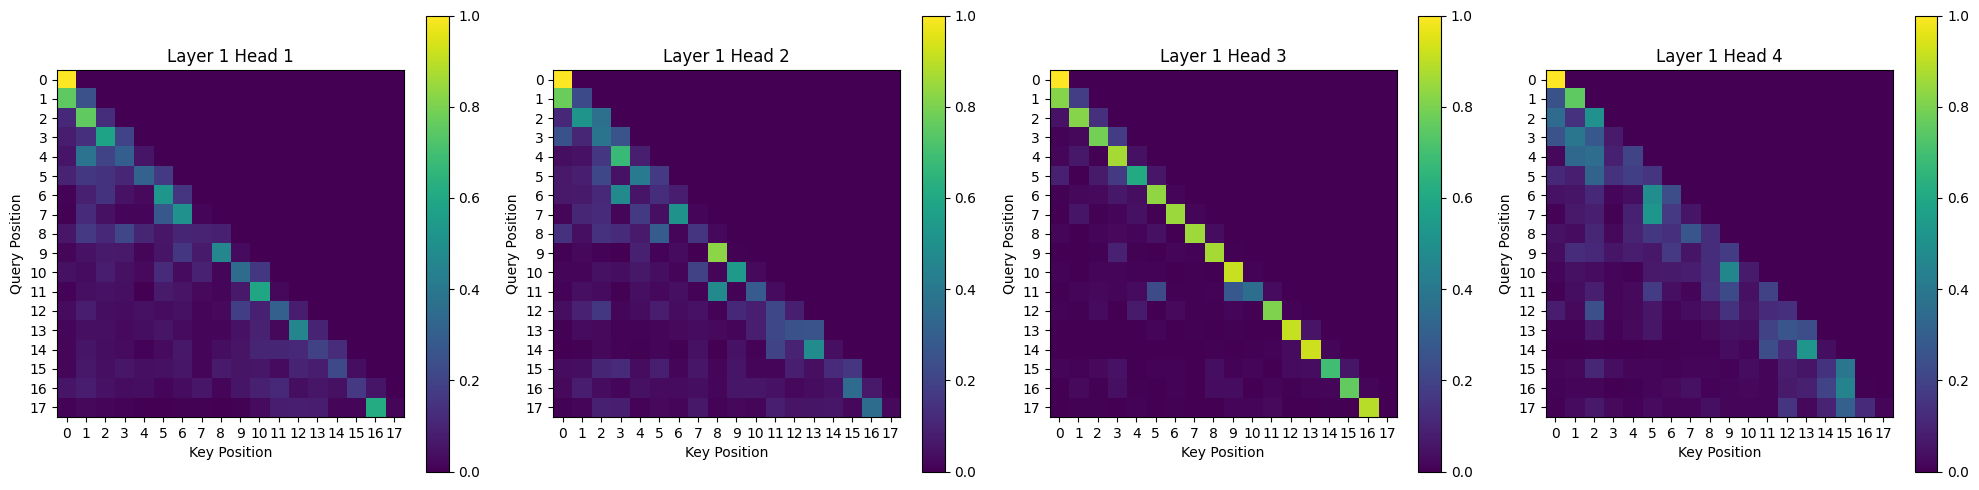

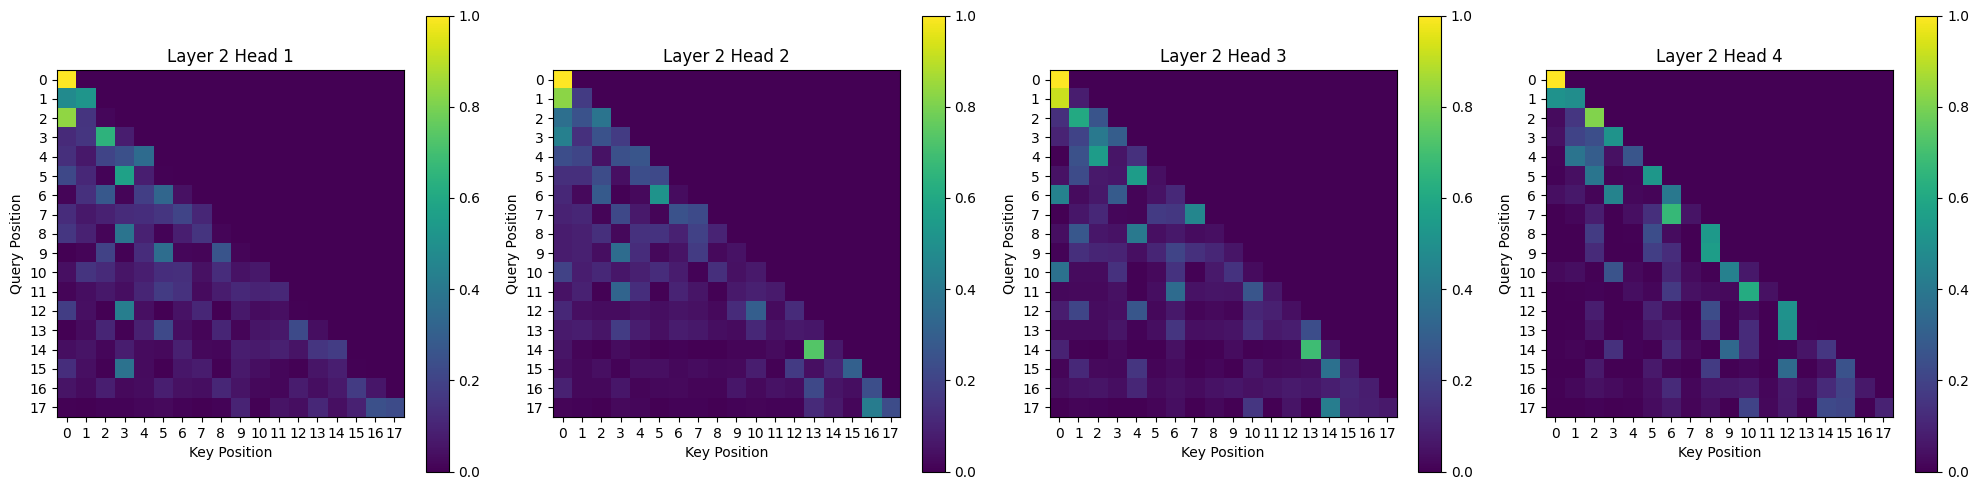

In [48]:
prompt = "To be or not to be"
visualize_attention(model, prompt)

# Conclusions

* **Temperature impact**: lower temperatures produce more deterministic output while higher temperature increase randomness. 
* **Moe**:
  - A lower loss was obtained from the model trained with MoE
  - MoE allows selective activation of experts rather than all parameters, potentially reducing computation at inference time.

# Congratulations! 🎉

After completing the tasks you've successfully pretrained for first GPT, remember to add your conclusions and findings! And you can now brag to your friend on how LLMs and GPTs work!

